# 4 — Diagnóstico em larga escala: explosões e árvores equivalentes

Este experimento executa **5.000 mecanismos aleatórios** em três horizontes de geração (96, 192 e 384 pontos) e investiga duas perguntas:

1. Como o limite imposto aos valores iniciais de entrada (x) altera a frequência e o tempo até a explosão das trajetórias?
2. Quantas árvores são repetidas ou equivalentes sob diferentes noções de normalização?

Nenhuma trajetória é recortada durante a recorrência: o limite aplica-se somente ao histórico inicial. Uma trajetória é classificada como explosiva quando produz valor não finito ou ultrapassa  (|x_t|>100). As mesmas árvores e inovações são reutilizadas em todos os limites de entrada, formando uma comparação pareada.


## 1. Configuração completa e reprodutibilidade

A gramática é a mesma família usada nos notebooks anteriores, agora com até seis operadores e apenas uma série, para permitir execução univariada. O terminal de tempo é desabilitado nesta análise para que crescimento determinístico em `t` não se confunda com instabilidade da recorrência.


In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import asdict
from pathlib import Path
import importlib.metadata
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tsfmxai").exists():
            return candidate
    raise RuntimeError("Repository root not found.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import (
    RandomTreeConfig,
    derive_sample_seed,
    evaluate_bound_expression,
    required_history_length,
    sample_random_mechanisms,
)
from tsfmxai.representations import (
    Add,
    Lag,
    Multiply,
    Parameter,
    Time,
    operator_count,
    parameter_slots,
    lag_slots,
    to_skeleton_formula,
    tree_depth,
    walk,
)

ROOT_SEED = 20261001
SAMPLE_COUNT = 5_000
GENERATED_HORIZONS = (96, 192, 384)
REFERENCE_HORIZON = 192
INNOVATION_STD = 0.05
ZERO_RADIUS_INNOVATION_STDS = 3.0
ZERO_TAIL_STEPS = 24
ZERO_RADIUS = ZERO_RADIUS_INNOVATION_STDS * INNOVATION_STD
INPUT_ABS_LIMITS = (0.0, 0.1, 0.5, 1.0, 2.0)
EXPLOSION_LIMIT = 100.0

TREE_CONFIG = RandomTreeConfig(
    minimum_operators=1,
    maximum_operators=6,
    num_series=1,
    minimum_lag=1,
    maximum_lag=12,
    parameter_probability=0.55,
    time_probability=0.0,
    lag_probability=0.45,
    add_probability=0.80,
    minimum_parameter_magnitude=0.05,
    maximum_parameter_magnitude=0.80,
    require_lag=True,
    require_time=False,
)

print(json.dumps({
    "root_seed": ROOT_SEED,
    "sample_count": SAMPLE_COUNT,
    "generated_horizons": GENERATED_HORIZONS,
    "innovation_std": INNOVATION_STD,
    "zero_radius": ZERO_RADIUS,
    "zero_tail_steps": ZERO_TAIL_STEPS,
    "input_absolute_limits": INPUT_ABS_LIMITS,
    "explosion_limit": EXPLOSION_LIMIT,
    "tree_config": asdict(TREE_CONFIG),
}, indent=2))

{
  "root_seed": 20261001,
  "sample_count": 5000,
  "generated_horizons": [
    96,
    192,
    384
  ],
  "innovation_std": 0.05,
  "zero_radius": 0.15000000000000002,
  "zero_tail_steps": 24,
  "input_absolute_limits": [
    0.0,
    0.1,
    0.5,
    1.0,
    2.0
  ],
  "explosion_limit": 100.0,
  "tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_magnitude": 0.05,
    "maximum_parameter_magnitude": 0.8,
    "require_lag": true,
    "require_time": false
  }
}


## 2. Amostrar milhares de mecanismos

Cada índice recebe uma semente derivada de `(ROOT_SEED, índice)`. Assim, aumentar a quantidade de amostras ou mudar a ordem de execução não altera os mecanismos já associados aos índices anteriores.


In [2]:
sampling_started = time.perf_counter()
mechanisms = sample_random_mechanisms(
    TREE_CONFIG,
    root_seed=ROOT_SEED,
    count=SAMPLE_COUNT,
)
sampling_seconds = time.perf_counter() - sampling_started

assert len(mechanisms) == SAMPLE_COUNT
assert mechanisms[:20] == sample_random_mechanisms(
    TREE_CONFIG, root_seed=ROOT_SEED, count=20
)
print(f"Mecanismos gerados: {len(mechanisms):,}")
print(f"Tempo de amostragem: {sampling_seconds:.3f} s")

Mecanismos gerados: 5,000
Tempo de amostragem: 1.669 s


## 3. Quatro noções de equivalência

As contagens abaixo respondem a perguntas diferentes:

- **Esqueleto atual:** representação canônica já usada pelo projeto; normaliza a troca local dos filhos de `+` e `*`.
- **AC:** também elimina diferenças de associação, por exemplo ((a+b)+c) versus (a+(b+c)).
- **Forma algébrica:** expande distributividade em um semianel com parâmetros anônimos; detecta formas como (p(a+b)) e (pa+pb). É deliberadamente **agnóstica aos valores dos coeficientes**, portanto indica equivalência de forma, não igualdade numérica das recorrências vinculadas.
- **Forma algébrica + lags:** mantém a expansão, mas inclui o valor inteiro de cada lag. Esta chave é mais estrita e pode dividir classes anteriores; aproxima melhor o mecanismo realizado.


In [3]:
def ac_fingerprint(node) -> str:
    if isinstance(node, Parameter):
        return "P"
    if isinstance(node, Time):
        return "T"
    if isinstance(node, Lag):
        return f"L[{node.variable}]"
    operator_type = Add if isinstance(node, Add) else Multiply
    label = "ADD" if operator_type is Add else "MUL"
    items = []
    def collect(current):
        if isinstance(current, operator_type):
            collect(current.left)
            collect(current.right)
        else:
            items.append(ac_fingerprint(current))
    collect(node)
    return f"{label}({','.join(sorted(items))})"


def expanded_polynomial(node, binding=None) -> Counter[tuple[str, ...]]:
    """Coefficient-agnostic polynomial shape under +, *, and distributivity."""
    if isinstance(node, Parameter):
        return Counter({("P",): 1})
    if isinstance(node, Time):
        return Counter({("T",): 1})
    if isinstance(node, Lag):
        token = f"L[{node.variable}]"
        if binding is not None:
            token += f"@{binding.lag_values[node.slot]}"
        return Counter({(token,): 1})
    if isinstance(node, Add):
        return expanded_polynomial(node.left, binding) + expanded_polynomial(node.right, binding)
    left = expanded_polynomial(node.left, binding)
    right = expanded_polynomial(node.right, binding)
    product = Counter()
    for left_monomial, left_count in left.items():
        for right_monomial, right_count in right.items():
            product[tuple(sorted(left_monomial + right_monomial))] += left_count * right_count
    return product


def polynomial_fingerprint(polynomial: Counter[tuple[str, ...]]) -> str:
    return " + ".join(
        f"{count}*{'·'.join(monomial)}"
        for monomial, count in sorted(polynomial.items())
    )


structure_rows = []
for mechanism in mechanisms:
    nodes = list(walk(mechanism.expression))
    multiply_count = sum(isinstance(node, Multiply) for node in nodes)
    parameters = tuple(mechanism.binding.parameter_values.values())
    structure_rows.append({
        "sample_index": mechanism.sample_index,
        "formula": mechanism.formula,
        "skeleton": mechanism.skeleton_formula,
        "ac_fingerprint": ac_fingerprint(mechanism.expression),
        "algebraic_shape": polynomial_fingerprint(expanded_polynomial(mechanism.expression)),
        "algebraic_bound_lags": polynomial_fingerprint(
            expanded_polynomial(mechanism.expression, mechanism.binding)
        ),
        "operator_count": operator_count(mechanism.expression),
        "tree_depth": tree_depth(mechanism.expression),
        "multiply_count": multiply_count,
        "lag_count": len(lag_slots(mechanism.expression)),
        "parameter_count": len(parameter_slots(mechanism.expression)),
        "max_abs_parameter": max(map(abs, parameters), default=0.0),
    })

structure = pd.DataFrame(structure_rows)
fingerprint_columns = ["skeleton", "ac_fingerprint", "algebraic_shape", "algebraic_bound_lags"]
equivalence_summary = pd.DataFrame([
    {
        "representação": column,
        "classes únicas": structure[column].nunique(),
        "fração única": structure[column].nunique() / SAMPLE_COUNT,
        "amostras em classes repetidas": int(structure[column].duplicated(keep=False).sum()),
        "maior classe": int(structure.groupby(column).size().max()),
    }
    for column in fingerprint_columns
]).set_index("representação")
equivalence_summary

,classes únicas,fração única,amostras em classes repetidas,maior classe
representação,,,,
skeleton,1858,0.3716,3630,532
ac_fingerprint,927,0.1854,4445,532
algebraic_shape,805,0.1610,4556,532
algebraic_bound_lags,3164,0.6328,2322,57


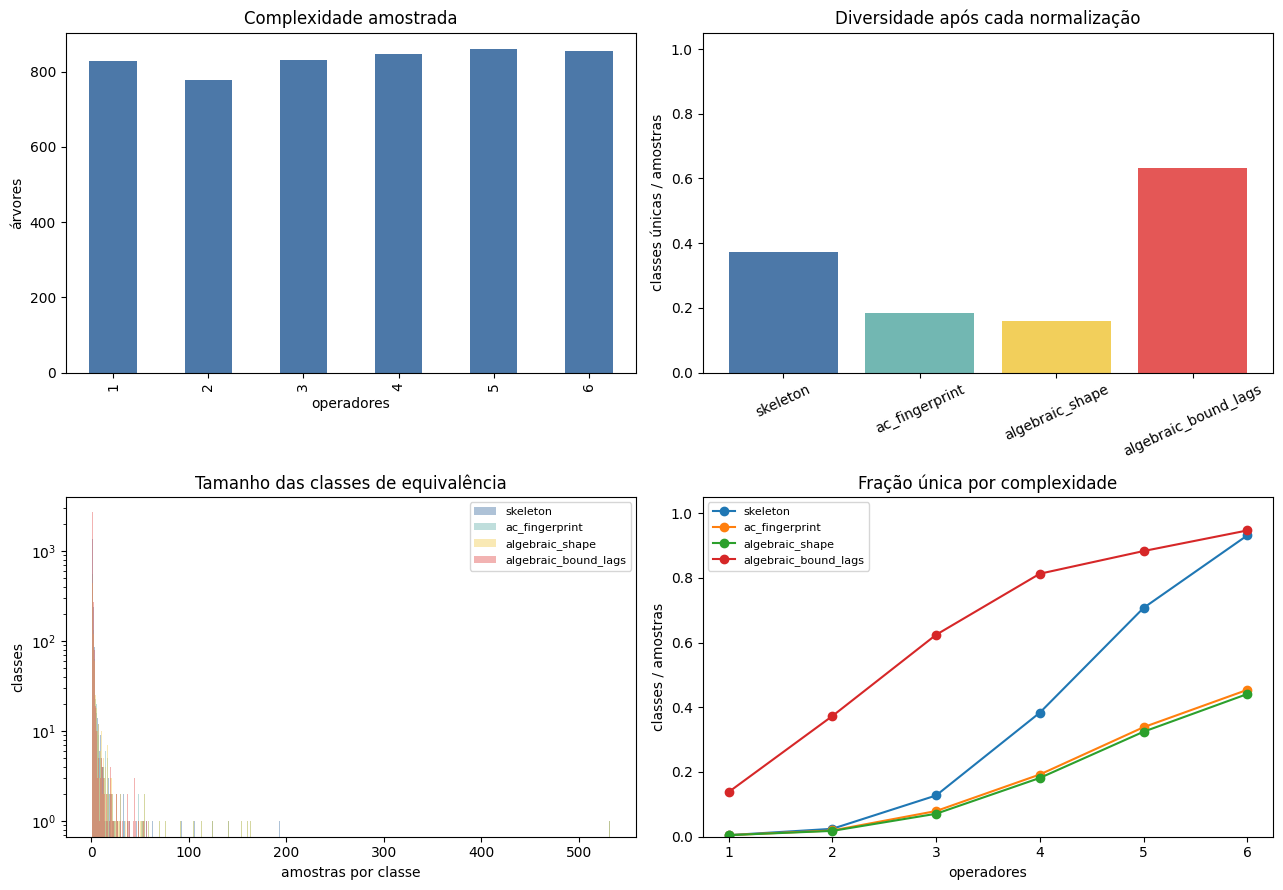

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

structure["operator_count"].value_counts().sort_index().plot.bar(ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set(title="Complexidade amostrada", xlabel="operadores", ylabel="árvores")

axes[0, 1].bar(
    equivalence_summary.index,
    equivalence_summary["fração única"],
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#E45756"],
)
axes[0, 1].set(title="Diversidade após cada normalização", ylabel="classes únicas / amostras", ylim=(0, 1.05))
axes[0, 1].tick_params(axis="x", rotation=25)

for column, color in zip(fingerprint_columns, ["#4C78A8", "#72B7B2", "#F2CF5B", "#E45756"]):
    sizes = structure.groupby(column).size()
    axes[1, 0].hist(sizes, bins=np.arange(1, sizes.max() + 2) - 0.5, alpha=0.45, label=column, color=color)
axes[1, 0].set(title="Tamanho das classes de equivalência", xlabel="amostras por classe", ylabel="classes", yscale="log")
axes[1, 0].legend(fontsize=8)

unique_by_complexity = structure.groupby("operator_count")[fingerprint_columns].nunique()
counts_by_complexity = structure.groupby("operator_count").size()
(unique_by_complexity.div(counts_by_complexity, axis=0)).plot(ax=axes[1, 1], marker="o")
axes[1, 1].set(title="Fração única por complexidade", xlabel="operadores", ylabel="classes / amostras", ylim=(0, 1.05))
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4. Simulação pareada com limites de entrada

Para cada mecanismo, primeiro é sorteado um vetor-base em `[-1, 1]`. Esse vetor é multiplicado por cada limite solicitado. As inovações gaussianas são idênticas entre limites para o mesmo mecanismo. Registramos o primeiro passo que cruza o limite, o maior módulo observado antes da parada e o motivo da explosão. Uma trajetória é classificada como `proxima_de_zero` quando não explode e **todos os seus 24 últimos valores gerados** permanecem a no máximo três desvios-padrão das inovações em relação a zero: `|x_t| <= 3 * 0.05 = 0.15`. Uma série é `constante_em_3_inovacoes` quando **todos os valores gerados** permanecem a no máximo três desvios-padrão das inovações de seu nível médio: `max(|x_t - mean(x)|) <= 0.15`. O histórico inicial é desconsiderado e séries explosivas não são constantes.


In [5]:
def simulate_with_input_limit(mechanism, input_abs_limit: float, generated_horizon: int) -> dict:
    history_length = required_history_length(mechanism.expression, mechanism.binding)
    sequence = np.random.SeedSequence([ROOT_SEED, int(mechanism.sample_index), 991])
    initialization_sequence, innovation_sequence = sequence.spawn(2)
    initialization_rng = np.random.default_rng(initialization_sequence)
    innovation_rng = np.random.default_rng(innovation_sequence)
    initial_values = initialization_rng.uniform(-1.0, 1.0, size=history_length) * input_abs_limit
    innovations = innovation_rng.normal(0.0, INNOVATION_STD, size=generated_horizon)
    values = list(map(float, initial_values))
    generated_values = []
    peak_abs = float(np.max(np.abs(initial_values))) if history_length else 0.0

    for step in range(generated_horizon):
        current_time = history_length + step
        next_value = evaluate_bound_expression(
            mechanism.expression,
            mechanism.binding,
            time=current_time,
            histories={0: values},
        ) + float(innovations[step])
        if not np.isfinite(next_value):
            return {"exploded": True, "near_zero": False, "constant_within_3sigma": False, "max_constant_deviation": np.nan, "zero_tail_peak_abs": np.nan, "explosion_step": step + 1, "reason": "non_finite", "peak_abs": np.inf}
        peak_abs = max(peak_abs, abs(next_value))
        if abs(next_value) > EXPLOSION_LIMIT:
            return {"exploded": True, "near_zero": False, "constant_within_3sigma": False, "max_constant_deviation": np.nan, "zero_tail_peak_abs": np.nan, "explosion_step": step + 1, "reason": "magnitude", "peak_abs": peak_abs}
        values.append(float(next_value))
        generated_values.append(float(next_value))
    zero_tail_peak_abs = float(np.max(np.abs(values[-ZERO_TAIL_STEPS:])))
    near_zero = zero_tail_peak_abs <= ZERO_RADIUS
    generated_array = np.asarray(generated_values)
    constant_level = float(np.mean(generated_array))
    max_constant_deviation = float(np.max(np.abs(generated_array - constant_level)))
    constant_within_3sigma = max_constant_deviation <= ZERO_RADIUS
    return {"exploded": False, "near_zero": near_zero, "constant_within_3sigma": constant_within_3sigma, "max_constant_deviation": max_constant_deviation, "zero_tail_peak_abs": zero_tail_peak_abs, "explosion_step": np.nan, "reason": "stable", "peak_abs": peak_abs}


simulation_started = time.perf_counter()
simulation_rows = []
for generated_horizon in GENERATED_HORIZONS:
    for input_abs_limit in INPUT_ABS_LIMITS:
        for mechanism in mechanisms:
            simulation_rows.append({
                "sample_index": mechanism.sample_index,
                "generated_horizon": generated_horizon,
                "input_abs_limit": input_abs_limit,
                **simulate_with_input_limit(mechanism, input_abs_limit, generated_horizon),
            })
        print(f"Concluído: horizonte={generated_horizon}, |x_inicial| <= {input_abs_limit:g}")

simulation_seconds = time.perf_counter() - simulation_started
simulations = pd.DataFrame(simulation_rows).merge(structure, on="sample_index", validate="many_to_one")
assert len(simulations) == SAMPLE_COUNT * len(INPUT_ABS_LIMITS) * len(GENERATED_HORIZONS)
reference_simulations = simulations[simulations["generated_horizon"].eq(REFERENCE_HORIZON)].copy()
print(f"Simulações: {len(simulations):,} em {simulation_seconds:.2f} s")

Concluído: horizonte=96, |x_inicial| <= 0


Concluído: horizonte=96, |x_inicial| <= 0.1


Concluído: horizonte=96, |x_inicial| <= 0.5


Concluído: horizonte=96, |x_inicial| <= 1


Concluído: horizonte=96, |x_inicial| <= 2


...

Concluído: horizonte=384, |x_inicial| <= 0


Concluído: horizonte=384, |x_inicial| <= 0.1


Concluído: horizonte=384, |x_inicial| <= 0.5


Concluído: horizonte=384, |x_inicial| <= 1


Concluído: horizonte=384, |x_inicial| <= 2
Simulações: 75,000 em 54.98 s


In [6]:
explosion_summary = simulations.groupby(["generated_horizon", "input_abs_limit"]).agg(
    mecanismos=("sample_index", "size"),
    explosões=("exploded", "sum"),
    próximas_de_zero=("near_zero", "sum"),
    séries_constantes_em_3_inovações=("constant_within_3sigma", "sum"),
    taxa_de_explosão=("exploded", "mean"),
    taxa_próximas_de_zero=("near_zero", "mean"),
    passo_mediano_da_explosão=("explosion_step", "median"),
    pico_mediano=("peak_abs", "median"),
)
explosion_summary["estáveis"] = explosion_summary["mecanismos"] - explosion_summary["explosões"]
explosion_summary["taxa_próximas_entre_estáveis"] = (
    explosion_summary["próximas_de_zero"] / explosion_summary["estáveis"]
)

# Wilson 95% interval for each binomial explosion rate.
z = 1.959963984540054
n = explosion_summary["mecanismos"].to_numpy()
p = explosion_summary["taxa_de_explosão"].to_numpy()
center = (p + z*z/(2*n)) / (1 + z*z/n)
half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
explosion_summary["IC95_inferior"] = center - half
explosion_summary["IC95_superior"] = center + half
horizon_tables = {
    horizon: explosion_summary.xs(horizon, level="generated_horizon")
    for horizon in GENERATED_HORIZONS
}
for horizon, table in horizon_tables.items():
    print(f"Horizonte de geração: {horizon} pontos")
    display(table)


Horizonte de geração: 96 pontos


,mecanismos,explosões,próximas_de_zero,séries_constantes_em_3_inovações,taxa_de_explosão,taxa_próximas_de_zero,passo_mediano_da_explosão,pico_mediano,estáveis,taxa_próximas_entre_estáveis,IC95_inferior,IC95_superior
input_abs_limit,,,,,,,,,,,,
0.0,5000,2093,575,557,0.4186,0.1150,37.0,16.069504,2907,0.197798,0.404993,0.432332
0.1,5000,2113,574,548,0.4226,0.1148,37.0,16.901360,2887,0.198822,0.408973,0.436346
0.5,5000,2206,564,332,0.4412,0.1128,35.0,20.530383,2794,0.201861,0.427487,0.455003
1.0,5000,2312,528,168,0.4624,0.1056,33.0,27.700088,2688,0.196429,0.448614,0.476243
2.0,5000,2554,392,74,0.5108,0.0784,27.0,100.625791,2446,0.160262,0.496941,0.524642


Horizonte de geração: 192 pontos


,mecanismos,explosões,próximas_de_zero,séries_constantes_em_3_inovações,taxa_de_explosão,taxa_próximas_de_zero,passo_mediano_da_explosão,pico_mediano,estáveis,taxa_próximas_entre_estáveis,IC95_inferior,IC95_superior
input_abs_limit,,,,,,,,,,,,
0.0,5000,2366,563,367,0.4732,0.1126,40.0,49.038291,2634,0.213743,0.459387,0.487054
0.1,5000,2369,563,367,0.4738,0.1126,40.0,49.315135,2631,0.213987,0.459985,0.487655
0.5,5000,2401,562,243,0.4802,0.1124,38.0,56.139051,2599,0.216237,0.466372,0.494058
1.0,5000,2487,522,127,0.4974,0.1044,35.0,88.849611,2513,0.207720,0.483548,0.511256
2.0,5000,2713,384,50,0.5426,0.0768,29.0,101.652183,2287,0.167906,0.528764,0.556371


Horizonte de geração: 384 pontos


,mecanismos,explosões,próximas_de_zero,séries_constantes_em_3_inovações,taxa_de_explosão,taxa_próximas_de_zero,passo_mediano_da_explosão,pico_mediano,estáveis,taxa_próximas_entre_estáveis,IC95_inferior,IC95_superior
input_abs_limit,,,,,,,,,,,,
0.0,5000,2573,554,183,0.5146,0.1108,44.0,100.182220,2427,0.228265,0.500741,0.528437
0.1,5000,2567,555,182,0.5134,0.1110,43.0,100.154064,2433,0.228113,0.499541,0.527238
0.5,5000,2593,554,135,0.5186,0.1108,40.0,100.214216,2407,0.230162,0.504742,0.532430
1.0,5000,2659,520,69,0.5318,0.1040,37.0,100.420907,2341,0.222127,0.517950,0.545601
2.0,5000,2881,385,28,0.5762,0.0770,30.0,102.014616,2119,0.181689,0.562449,0.589834


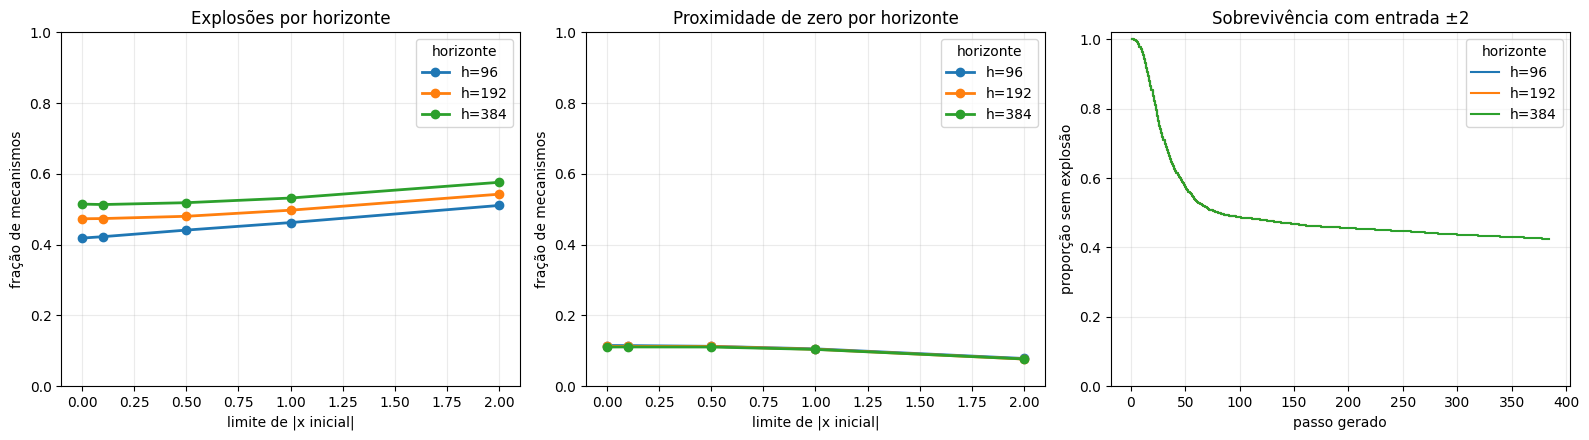

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for horizon, table in horizon_tables.items():
    x = table.index.to_numpy()
    axes[0].plot(x, table["taxa_de_explosão"], marker="o", linewidth=2, label=f"h={horizon}")
    axes[1].plot(x, table["taxa_próximas_de_zero"], marker="o", linewidth=2, label=f"h={horizon}")
axes[0].set(title="Explosões por horizonte", xlabel="limite de |x inicial|", ylabel="fração de mecanismos", ylim=(0, 1))
axes[1].set(title="Proximidade de zero por horizonte", xlabel="limite de |x inicial|", ylabel="fração de mecanismos", ylim=(0, 1))
for axis in axes[:2]:
    axis.legend(title="horizonte"); axis.grid(alpha=0.25)

largest_limit = max(INPUT_ABS_LIMITS)
for horizon in GENERATED_HORIZONS:
    group = simulations[simulations["generated_horizon"].eq(horizon) & simulations["input_abs_limit"].eq(largest_limit)]
    survival = 1.0 - np.asarray([(group["explosion_step"].fillna(np.inf) <= step).mean() for step in range(1, horizon + 1)])
    axes[2].step(range(1, horizon + 1), survival, where="post", label=f"h={horizon}")
axes[2].set(title=f"Sobrevivência com entrada ±{largest_limit:g}", xlabel="passo gerado", ylabel="proporção sem explosão", ylim=(0, 1.02))
axes[2].grid(alpha=0.25); axes[2].legend(title="horizonte")

fig.tight_layout()
plt.show()

## 5. Quais estruturas mais explodem?

As tabelas e gráficos seguintes estratificam o risco por quantidade de multiplicações, complexidade total, número de lags e magnitude máxima dos parâmetros. Isso ajuda a separar o efeito do tamanho da entrada do efeito da gramática.


In [8]:
risk_by_multiplication = reference_simulations.pivot_table(
    index="multiply_count",
    columns="input_abs_limit",
    values="exploded",
    aggfunc=["mean", "size"],
)
risk_by_multiplication

mean                                          size        \
input_abs_limit       0.0       0.1       0.5       1.0       2.0   0.0   0.1   
multiply_count                                                                  
0                0.559224  0.559224  0.559224  0.559224  0.559224  2423  2423   
1                0.434807  0.436464  0.444751  0.478453  0.557459  1810  1810   
2                0.347176  0.345515  0.368771  0.401993  0.503322   602   602   
3                0.102190  0.109489  0.131387  0.153285  0.299270   137   137   
4                0.038462  0.038462  0.038462  0.115385  0.192308    26    26   
5                0.000000  0.000000  0.000000  0.000000  0.000000     2     2   

                                   
input_abs_limit   0.5   1.0   2.0  
multiply_count                     
0                2423  2423  2423  
1                1810  1810  1810  
2                 602   602   602  
3                 137   137   137  
4                  26    26    26  
5                   2     2     2

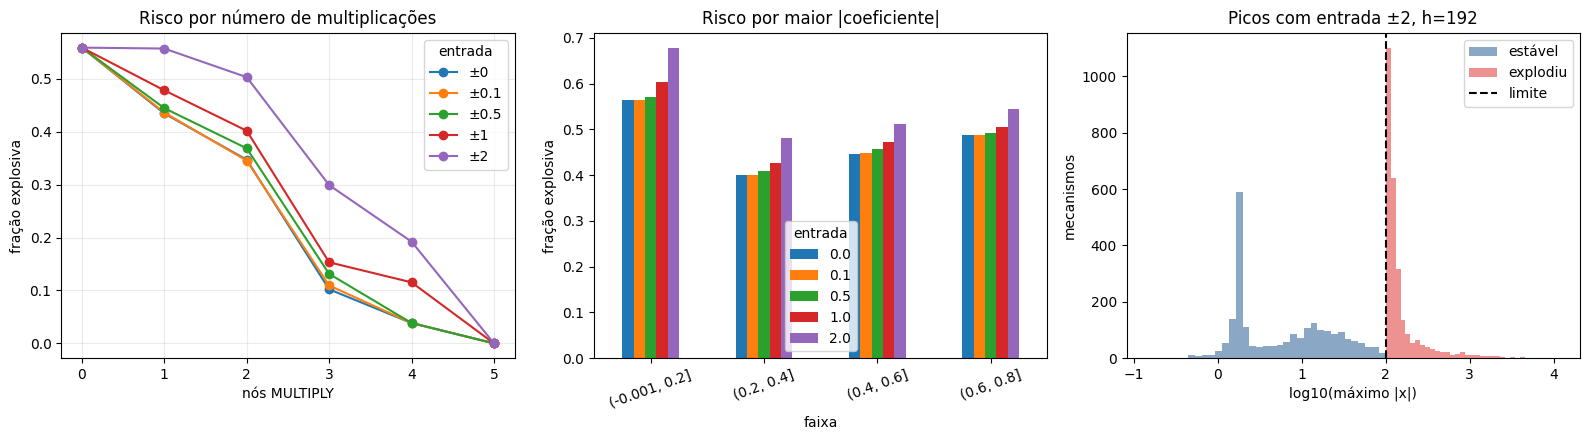

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for limit, group in reference_simulations.groupby("input_abs_limit"):
    grouped = group.groupby("multiply_count")["exploded"].mean()
    axes[0].plot(grouped.index, grouped, marker="o", label=f"±{limit:g}")
axes[0].set(title="Risco por número de multiplicações", xlabel="nós MULTIPLY", ylabel="fração explosiva")
axes[0].legend(title="entrada"); axes[0].grid(alpha=0.25)

parameter_bins = pd.cut(reference_simulations["max_abs_parameter"], bins=[0, .2, .4, .6, .8], include_lowest=True)
parameter_risk = reference_simulations.assign(parameter_bin=parameter_bins).pivot_table(index="parameter_bin", columns="input_abs_limit", values="exploded", aggfunc="mean", observed=True)
parameter_risk.plot.bar(ax=axes[1])
axes[1].set(title="Risco por maior |coeficiente|", xlabel="faixa", ylabel="fração explosiva")
axes[1].tick_params(axis="x", rotation=20); axes[1].legend(title="entrada")

largest_limit = max(INPUT_ABS_LIMITS)
largest = reference_simulations[reference_simulations["input_abs_limit"].eq(largest_limit)]
peak_values = np.log10(np.maximum(largest["peak_abs"].replace(np.inf, EXPLOSION_LIMIT*10), 1e-8))
for exploded, label, color in [(False, "estável", "#4C78A8"), (True, "explodiu", "#E45756")]:
    axes[2].hist(peak_values[largest["exploded"].eq(exploded)], bins=35, alpha=.65, label=label, color=color)
axes[2].axvline(np.log10(EXPLOSION_LIMIT), color="black", linestyle="--", label="limite")
axes[2].set(title=f"Picos com entrada ±{largest_limit:g}, h={REFERENCE_HORIZON}", xlabel="log10(máximo |x|)", ylabel="mecanismos")
axes[2].legend()

fig.tight_layout(); plt.show()

In [10]:
non_monotonic_by_horizon = {}
for horizon, horizon_group in simulations.groupby("generated_horizon"):
    paired = horizon_group.pivot(index="sample_index", columns="input_abs_limit", values="exploded").astype(int)
    non_monotonic_by_horizon[int(horizon)] = int((np.diff(paired.to_numpy(), axis=1) < 0).any(axis=1).sum())

lowest_exploders = reference_simulations[
    reference_simulations["input_abs_limit"].eq(min(INPUT_ABS_LIMITS)) & reference_simulations["exploded"]
].sort_values("explosion_step").head(8)[
    ["sample_index", "formula", "operator_count", "multiply_count", "explosion_step", "peak_abs"]
]

print(f"Classificações não monotônicas por horizonte: {non_monotonic_by_horizon}")
print(f"Explosões mais precoces com entrada inicial zero e horizonte {REFERENCE_HORIZON}:")
lowest_exploders

Classificações não monotônicas por horizonte: {96: 20, 192: 13, 384: 12}
Explosões mais precoces com entrada inicial zero e horizonte 192:


,sample_index,formula,operator_count,multiply_count,explosion_step,peak_abs
28687,3687,((((x_0(t-6) + x_0(t-1)) * (x_0(t-2) + 0.26250...,5,1,6.0,121.349426
26326,1326,(((((-0.346466 * -0.0543717) + -0.612815) + x_...,5,1,6.0,212.725784
27541,2541,((((x_0(t-1) + x_0(t-1)) + ((x_0(t-3) + -0.274...,6,1,6.0,229.479186
25960,960,((x_0(t-1) + 0.688638) + (x_0(t-1) + 0.74035)),3,0,7.0,176.179386
29568,4568,((((((x_0(t-1) + 0.37399) + x_0(t-5)) + x_0(t-...,6,0,7.0,220.707976
26327,1327,((((((x_0(t-5) + -0.181894) + -0.42881) + x_0(...,6,0,7.0,184.779761
25842,842,(((((x_0(t-11) + x_0(t-2)) + x_0(t-5)) * (x_0(...,6,1,7.0,145.425586
26163,1163,((((((x_0(t-5) + x_0(t-1)) + x_0(t-10)) + -0.1...,6,0,7.0,106.578659


In [11]:
baseline_limit = min(INPUT_ABS_LIMITS)
baseline_risk = reference_simulations[reference_simulations["input_abs_limit"].eq(baseline_limit)].groupby("multiply_count")["exploded"].agg(["size", "mean"])
largest_limit_risk = reference_simulations[reference_simulations["input_abs_limit"].eq(max(INPUT_ABS_LIMITS))].groupby("multiply_count")["exploded"].agg(["size", "mean"])
reference_summary = horizon_tables[REFERENCE_HORIZON]

print(
    f"No horizonte {REFERENCE_HORIZON}, a taxa total cresceu de {reference_summary.loc[min(INPUT_ABS_LIMITS), 'taxa_de_explosão']:.2%} "
    f"para {reference_summary.loc[max(INPUT_ABS_LIMITS), 'taxa_de_explosão']:.2%}."
)
print(
    f"A taxa de trajetórias próximas de zero variou de "
    f"{reference_summary.loc[min(INPUT_ABS_LIMITS), 'taxa_próximas_de_zero']:.2%} para "
    f"{reference_summary.loc[max(INPUT_ABS_LIMITS), 'taxa_próximas_de_zero']:.2%}."
)
print(
    "A hipótese de maior risco com mais MULTIPLY foi contrariada: "
    f"com entrada zero, árvores sem MULTIPLY explodiram a {baseline_risk.loc[0, 'mean']:.2%}, "
    f"contra {baseline_risk.loc[1:, 'mean'].mean():.2%} na média não ponderada das demais faixas."
)
print(
    "Interpretação: lags aditivos têm coeficiente implícito 1; somá-los repetidamente pode criar "
    "ganho autoregressivo > 1, enquanto produtos frequentemente incluem parâmetros de módulo < 0,8."
)
display(pd.concat({"entrada_zero": baseline_risk, "maior_entrada": largest_limit_risk}, axis=1))

No horizonte 192, a taxa total cresceu de 47.32% para 54.26%.
A taxa de trajetórias próximas de zero variou de 11.26% para 7.68%.
A hipótese de maior risco com mais MULTIPLY foi contrariada: com entrada zero, árvores sem MULTIPLY explodiram a 55.92%, contra 18.45% na média não ponderada das demais faixas.
Interpretação: lags aditivos têm coeficiente implícito 1; somá-los repetidamente pode criar ganho autoregressivo > 1, enquanto produtos frequentemente incluem parâmetros de módulo < 0,8.


entrada_zero           maior_entrada          
                       size      mean          size      mean
multiply_count                                               
0                      2423  0.559224          2423  0.559224
1                      1810  0.434807          1810  0.557459
2                       602  0.347176           602  0.503322
3                       137  0.102190           137  0.299270
4                        26  0.038462            26  0.192308
5                         2  0.000000             2  0.000000

## 6. Inspecionar colisões de equivalência

Os exemplos abaixo mostram classes que somente aparecem depois da normalização AC ou da expansão distributiva. Elas são úteis para decidir se o gerador deve rejeitar duplicatas antes de simular trajetórias.


In [12]:
def collision_examples(fingerprint: str, baseline: str, maximum_groups: int = 5) -> pd.DataFrame:
    rows = []
    for key, group in structure.groupby(fingerprint):
        distinct_baselines = group[baseline].drop_duplicates()
        if len(distinct_baselines) < 2:
            continue
        distinct_skeletons = group["skeleton"].drop_duplicates()
        rows.append({
            "fingerprint": key,
            "class_size": len(group),
            f"distinct_{baseline}": len(distinct_baselines),
            "example_1": distinct_skeletons.iloc[0],
            "example_2": distinct_skeletons.iloc[1],
        })
    return pd.DataFrame(rows).sort_values(
        ["class_size", f"distinct_{baseline}"], ascending=False
    ).head(maximum_groups)


print("Colisões adicionais encontradas por associatividade + comutatividade:")
display(collision_examples("ac_fingerprint", baseline="skeleton"))
print("Colisões adicionais da expansão distributiva, além das já explicadas por AC:")
display(collision_examples("algebraic_shape", baseline="ac_fingerprint"))

Colisões adicionais encontradas por associatividade + comutatividade:


,fingerprint,class_size,distinct_skeleton,example_1,example_2
144,"ADD(L[0],P,P)",286,2,"((P0 + P1) + LAG(0, L0))","((LAG(0, L0) + P0) + P1)"
68,"ADD(L[0],L[0],P)",163,2,"((LAG(0, L0) + P0) + LAG(0, L1))","((LAG(0, L0) + LAG(0, L1)) + P0)"
145,"ADD(L[0],P,P,P)",160,4,"(((P0 + P1) + P2) + LAG(0, L0))","(((P0 + P1) + LAG(0, L0)) + P2)"
69,"ADD(L[0],L[0],P,P)",154,6,"(((LAG(0, L0) + P0) + P1) + LAG(0, L1))","((LAG(0, L0) + P0) + (LAG(0, L1) + P1))"
70,"ADD(L[0],L[0],P,P,P)",113,15,"((((LAG(0, L0) + P0) + LAG(0, L1)) + P1) + P2)","(((LAG(0, L0) + P0) + P1) + (LAG(0, L1) + P2))"


Colisões adicionais da expansão distributiva, além das já explicadas por AC:


,fingerprint,class_size,distinct_ac_fingerprint,example_1,example_2
44,1*L[0]·P + 1*P·P,51,2,"((LAG(0, L0) + P0) * P1)","((LAG(0, L0) * P0) + (P1 * P2))"
27,1*L[0]·L[0] + 1*L[0]·P,35,2,"((LAG(0, L0) + P0) * LAG(0, L1))","((LAG(0, L0) * LAG(0, L1)) + (LAG(0, L2) * P0))"
78,2*L[0]·P + 2*P·P,30,4,"((((LAG(0, L0) + P0) + LAG(0, L1)) + P1) * P2)","((LAG(0, L0) + P0) * (P1 + P2))"
72,2*L[0]·P,28,3,"((P0 + P1) * LAG(0, L0))","((LAG(0, L0) + LAG(0, L1)) * P0)"
42,1*L[0]·P + 1*P + 1*P·P,21,2,"(((LAG(0, L0) + P0) * P1) + P2)","(((LAG(0, L0) * P0) + (P1 * P2)) + P3)"


## 7. Leituras e análises recomendadas

Este notebook cobre estabilidade numérica e equivalência estrutural/algebraica. Próximos testes úteis:

1. **Reamostrar coeficientes para o mesmo esqueleto:** separa instabilidade da topologia da instabilidade da parametrização.
2. **Mapa em duas dimensões ((|x_0|,sigma_epsilon)):** mede a interação entre condição inicial e inovação.
3. **Vários horizontes e limites de explosão:** uma árvore pode parecer estável em 192 passos e divergir em 1.024; curvas por horizonte evitam uma classificação binária arbitrária.
4. **Expoente de Lyapunov por diferenças finitas:** perturbar levemente o mesmo histórico quantifica sensibilidade mesmo quando nenhuma trajetória cruza 100.
5. **Assinatura comportamental em painel de sondas:** avaliar mecanismos em muitos históricos artificiais e agrupar vetores de saída normalizados detecta quase-equivalências que a álgebra simbólica não captura.
6. **Simplificação com SymPy sob premissas declaradas:** constant folding, termos nulos, fatores comuns e polinômios expandidos podem formar uma chave semântica mais rigorosa. Parâmetros independentes não devem ser tratados como iguais sem explicitar essa aproximação.
7. **Cobertura ponderada:** medir entropia e tamanho efetivo das classes, não apenas quantidade de fórmulas únicas, para saber se poucas famílias dominam o corpus.
8. **Rejeição antecipada por risco:** usar multiplicações, grau polinomial, magnitude dos coeficientes e lags como filtro barato antes da simulação completa, validando o filtro contra falsos negativos.


## 8. Registro completo do experimento

A célula abaixo é o registro único deste experimento executado: pergunta, hipótese, configuração, proveniência, sementes, métricas, resumo científico e comando de reprodução.


In [13]:
package_versions = {
    name: importlib.metadata.version(name)
    for name in ["numpy", "pandas", "matplotlib"]
}
explosion_metrics = {
    str(horizon): {
        str(limit): {
            "count": int(row["explosões"]),
            "near_zero_count": int(row["próximas_de_zero"]),
            "constant_within_3_innovations_count": int(row["séries_constantes_em_3_inovações"]),
            "near_zero_rate": float(row["taxa_próximas_de_zero"]),
            "near_zero_rate_among_stable": float(row["taxa_próximas_entre_estáveis"]),
            "rate": float(row["taxa_de_explosão"]),
            "median_explosion_step": None if pd.isna(row["passo_mediano_da_explosão"]) else float(row["passo_mediano_da_explosão"]),
            "wilson_95": [float(row["IC95_inferior"]), float(row["IC95_superior"])],
        }
        for limit, row in table.iterrows()
    }
    for horizon, table in horizon_tables.items()
}
equivalence_metrics = {
    index: {
        "unique_classes": int(row["classes únicas"]),
        "unique_fraction": float(row["fração única"]),
        "samples_in_repeated_classes": int(row["amostras em classes repetidas"]),
        "largest_class": int(row["maior classe"]),
    }
    for index, row in equivalence_summary.iterrows()
}

experiment_record = {
    "experiment_id": "abstract_syntax_tree_004_large_scale_stability_equivalence",
    "status": "executed",
    "research_question": (
        "How often do randomly sampled recurrent ASTs explode as the generation horizon and initial x range change, "
        "and how much apparent diversity remains after increasingly strong equivalence normalizations?"
    ),
    "hypothesis": (
        "Explosion risk increases with the generation horizon, initial-value bound, and multiplicative structure; "
        "associative and distributive normalization reveals duplicates not removed by local commutative canonicalization."
    ),
    "configuration": {
        "sample_count": SAMPLE_COUNT,
        "generated_horizons": list(GENERATED_HORIZONS),
        "reference_horizon_for_detailed_structure_plots": REFERENCE_HORIZON,
        "innovation_std": INNOVATION_STD,
        "near_zero_definition": {
            "radius_in_innovation_standard_deviations": ZERO_RADIUS_INNOVATION_STDS,
            "absolute_radius": ZERO_RADIUS,
            "required_final_steps_inside_radius": ZERO_TAIL_STEPS,
            "requires_non_exploded_trajectory": True,
        },
        "constant_within_3_innovations_definition": {
            "scope": "all generated values; initial history excluded",
            "criterion": "max(abs(x - mean(x))) <= 3 * innovation_std",
            "maximum_deviation_from_series_mean": ZERO_RADIUS,
            "requires_non_exploded_trajectory": True,
        },
        "input_absolute_limits": list(INPUT_ABS_LIMITS),
        "explosion_limit": EXPLOSION_LIMIT,
        "tree": asdict(TREE_CONFIG),
    },
    "seed_policy": {
        "root_seed": ROOT_SEED,
        "mechanism_seed": "derive_sample_seed(ROOT_SEED, sample_index)",
        "paired_trajectory_seed": "SeedSequence([ROOT_SEED, sample_index, 991])",
        "same_innovations_across_input_limits": True,
        "shorter_horizons_are_prefixes_of_longer_horizons": True,
    },
    "provenance": {
        "implementation": [
            "src/tsfmxai/generators/random_expression.py",
            "src/tsfmxai/generators/trajectory.py",
            "src/tsfmxai/representations/expression.py",
        ],
        "python": sys.version,
        "platform": platform.platform(),
        "packages": package_versions,
    },
    "metrics": {
        "sampling_seconds": sampling_seconds,
        "simulation_seconds": simulation_seconds,
        "outcomes_by_horizon_and_input_limit": explosion_metrics,
        "equivalence": equivalence_metrics,
        "non_monotonic_explosion_classifications_by_horizon": non_monotonic_by_horizon,
    },
    "scientific_summary": (
        f"At the reference horizon {REFERENCE_HORIZON}, explosion frequency increased from "
        f"{reference_summary.loc[min(INPUT_ABS_LIMITS), 'taxa_de_explosão']:.2%} at zero initial input to "
        f"{reference_summary.loc[max(INPUT_ABS_LIMITS), 'taxa_de_explosão']:.2%} at the largest bound. "
        f"The fraction remaining within three innovation standard deviations of zero for all final {ZERO_TAIL_STEPS} steps "
        f"changed from {reference_summary.loc[min(INPUT_ABS_LIMITS), 'taxa_próximas_de_zero']:.2%} to "
        f"{reference_summary.loc[max(INPUT_ABS_LIMITS), 'taxa_próximas_de_zero']:.2%}. "
        f"Series whose complete generated range stayed within three innovation standard deviations were observed "
        f"{int(explosion_summary['séries_constantes_em_3_inovações'].sum())} times across all horizon-bound runs. "
        f"Only {equivalence_summary.loc['skeleton', 'fração única']:.2%} of current canonical skeletons and "
        f"{equivalence_summary.loc['algebraic_shape', 'fração única']:.2%} of coefficient-agnostic algebraic shapes were unique. "
        "The multiplicative-risk hypothesis was contradicted: additive lag sums dominated explosions because lag leaves have "
        "implicit unit coefficients, while products often introduce sub-unit sampled parameters. Algebraic-shape collisions "
        "are deduplication candidates, not proof that independently bound numerical recurrences are identical."
    ),
    "reproduction_command": (
        "python -m jupyter nbconvert --to notebook --execute "
        "experiments/abstract_syntax_tree/4_large_scale_stability_and_equivalence.ipynb "
        "--inplace --ExecutePreprocessor.timeout=2400"
    ),
}

print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

{
  "experiment_id": "abstract_syntax_tree_004_large_scale_stability_equivalence",
  "status": "executed",
  "research_question": "How often do randomly sampled recurrent ASTs explode as the generation horizon and initial x range change, and how much apparent diversity remains after increasingly strong equivalence normalizations?",
  "hypothesis": "Explosion risk increases with the generation horizon, initial-value bound, and multiplicative structure; associative and distributive normalization reveals duplicates not removed by local commutative canonicalization.",
  "configuration": {
    "sample_count": 5000,
    "generated_horizons": [
      96,
      192,
      384
    ],
    "reference_horizon_for_detailed_structure_plots": 192,
    "innovation_std": 0.05,
    "near_zero_definition": {
      "radius_in_innovation_standard_deviations": 3.0,
      "absolute_radius": 0.15000000000000002,
      "required_final_steps_inside_radius": 24,
      "requires_non_exploded_trajectory": true
   

**Interpretação do registro.** O resultado é um diagnóstico empírico condicionado à configuração declarada. Em especial, a forma algébrica com parâmetros anônimos é uma ferramenta de triagem de redundância estrutural e não deve substituir uma prova de equivalência com coeficientes independentes.
